# US Recession 2025 Forecast - Data Exploration

This notebook explores the economic indicators used in the US Recession 2025 forecast model (v2).

## Objectives
1. Load and visualize all economic indicators
2. Generate statistical summaries
3. Analyze correlations between indicators
4. Identify missing data and data quality issues
5. Mark historical recession periods for context

In [3]:
# Add project root to path
import sys
from pathlib import Path

# Add project root (3 levels up from this notebook)
project_root = Path().absolute().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/simon/Documents/perso/polymarket-simulator


In [4]:
# Import data fetching utilities
from forecasts.us_recession_2025.data_v2 import fetch_economic_indicators_v2
from forecasts.us_recession_2025.config import DATA_SOURCES
from forecasts.us_recession_2025.config_v2 import V2_INDICATOR_SERIES, get_all_indicator_thresholds
from lib.data_fetcher import fetch_fred_data

# Import data analysis libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Historical Recession Periods

We'll mark these periods on our visualizations for context.

In [5]:
# Historical US recession periods (NBER dates)
RECESSION_PERIODS = [
    ('2020-02-01', '2020-04-30'),  # COVID-19 recession
    ('2007-12-01', '2009-06-30'),  # Great Recession
    ('2001-03-01', '2001-11-30'),  # Dot-com bubble recession
]

# Convert to datetime
recession_periods = [(pd.to_datetime(start), pd.to_datetime(end)) 
                     for start, end in RECESSION_PERIODS]

print(f"Tracking {len(recession_periods)} historical recession periods")

Tracking 3 historical recession periods


## Load Historical Data

Fetching 5 years (1825 days) of historical data for all indicators.

In [6]:
# Fetch 5 years of data
lookback_days = 1825  # 5 years
end_date = datetime.now()
start_date = end_date - timedelta(days=lookback_days)

print(f"Fetching data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print("This may take a minute...\n")

# Get all indicator series IDs
all_indicators = {**DATA_SOURCES, **V2_INDICATOR_SERIES}

# Fetch data for each indicator
indicator_data = {}
for indicator_name, series_id in all_indicators.items():
    try:
        print(f"Fetching {indicator_name} ({series_id})...")
        data = fetch_fred_data(
            series_id=series_id,
            start_date=start_date.strftime('%Y-%m-%d'),
            end_date=end_date.strftime('%Y-%m-%d')
        )
        indicator_data[indicator_name] = data
    except Exception as e:
        print(f"  ⚠ Error fetching {indicator_name}: {e}")
        indicator_data[indicator_name] = None

print(f"\n✓ Successfully fetched data for {len([v for v in indicator_data.values() if v])} indicators")

Fetching data from 2020-11-23 to 2025-11-22
This may take a minute...

Fetching yield_curve (T10Y2Y)...
Fetching unemployment (UNRATE)...
Fetching gdp (A191RL1Q225SBEA)...
Fetching consumer_confidence (UMCSENT)...
Fetching leading_indicators (USSLIND)...
Fetching jobless_claims (ICSA)...
Fetching credit_spread (BAA10Y)...
Fetching housing_starts (HOUST)...
Fetching manufacturing_pmi (NAPM)...


FRED API request failed with status 400: Bad Request.  The series does not exist.


  ⚠ Error fetching manufacturing_pmi: FRED API request failed with status 400: Bad Request.  The series does not exist.
Fetching retail_sales (RSXFS)...
Fetching oil_price (DCOILWTICO)...
Fetching vix (VIXCLS)...

✓ Successfully fetched data for 11 indicators


In [7]:
# Convert each indicator to a DataFrame
dfs = {}

for indicator_name, data in indicator_data.items():
    if data is None:
        continue
    
    observations = data.get('observations', [])
    if not observations:
        continue
    
    # Create DataFrame
    df = pd.DataFrame(observations)
    df['date'] = pd.to_datetime(df['date'])
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df[['date', 'value']].set_index('date')
    df.columns = [indicator_name]
    
    dfs[indicator_name] = df

# Combine all indicators into a single DataFrame
combined_df = pd.concat(dfs.values(), axis=1)
combined_df = combined_df.sort_index()

print(f"Combined DataFrame shape: {combined_df.shape}")
print(f"Date range: {combined_df.index.min()} to {combined_df.index.max()}")
print(f"\nIndicators: {list(combined_df.columns)}")

Combined DataFrame shape: (1574, 10)
Date range: 2020-10-01 00:00:00 to 2025-11-21 00:00:00

Indicators: ['yield_curve', 'unemployment', 'gdp', 'consumer_confidence', 'jobless_claims', 'credit_spread', 'housing_starts', 'retail_sales', 'oil_price', 'vix']


## Time Series Visualization

Plotting each indicator over time with recession periods marked.

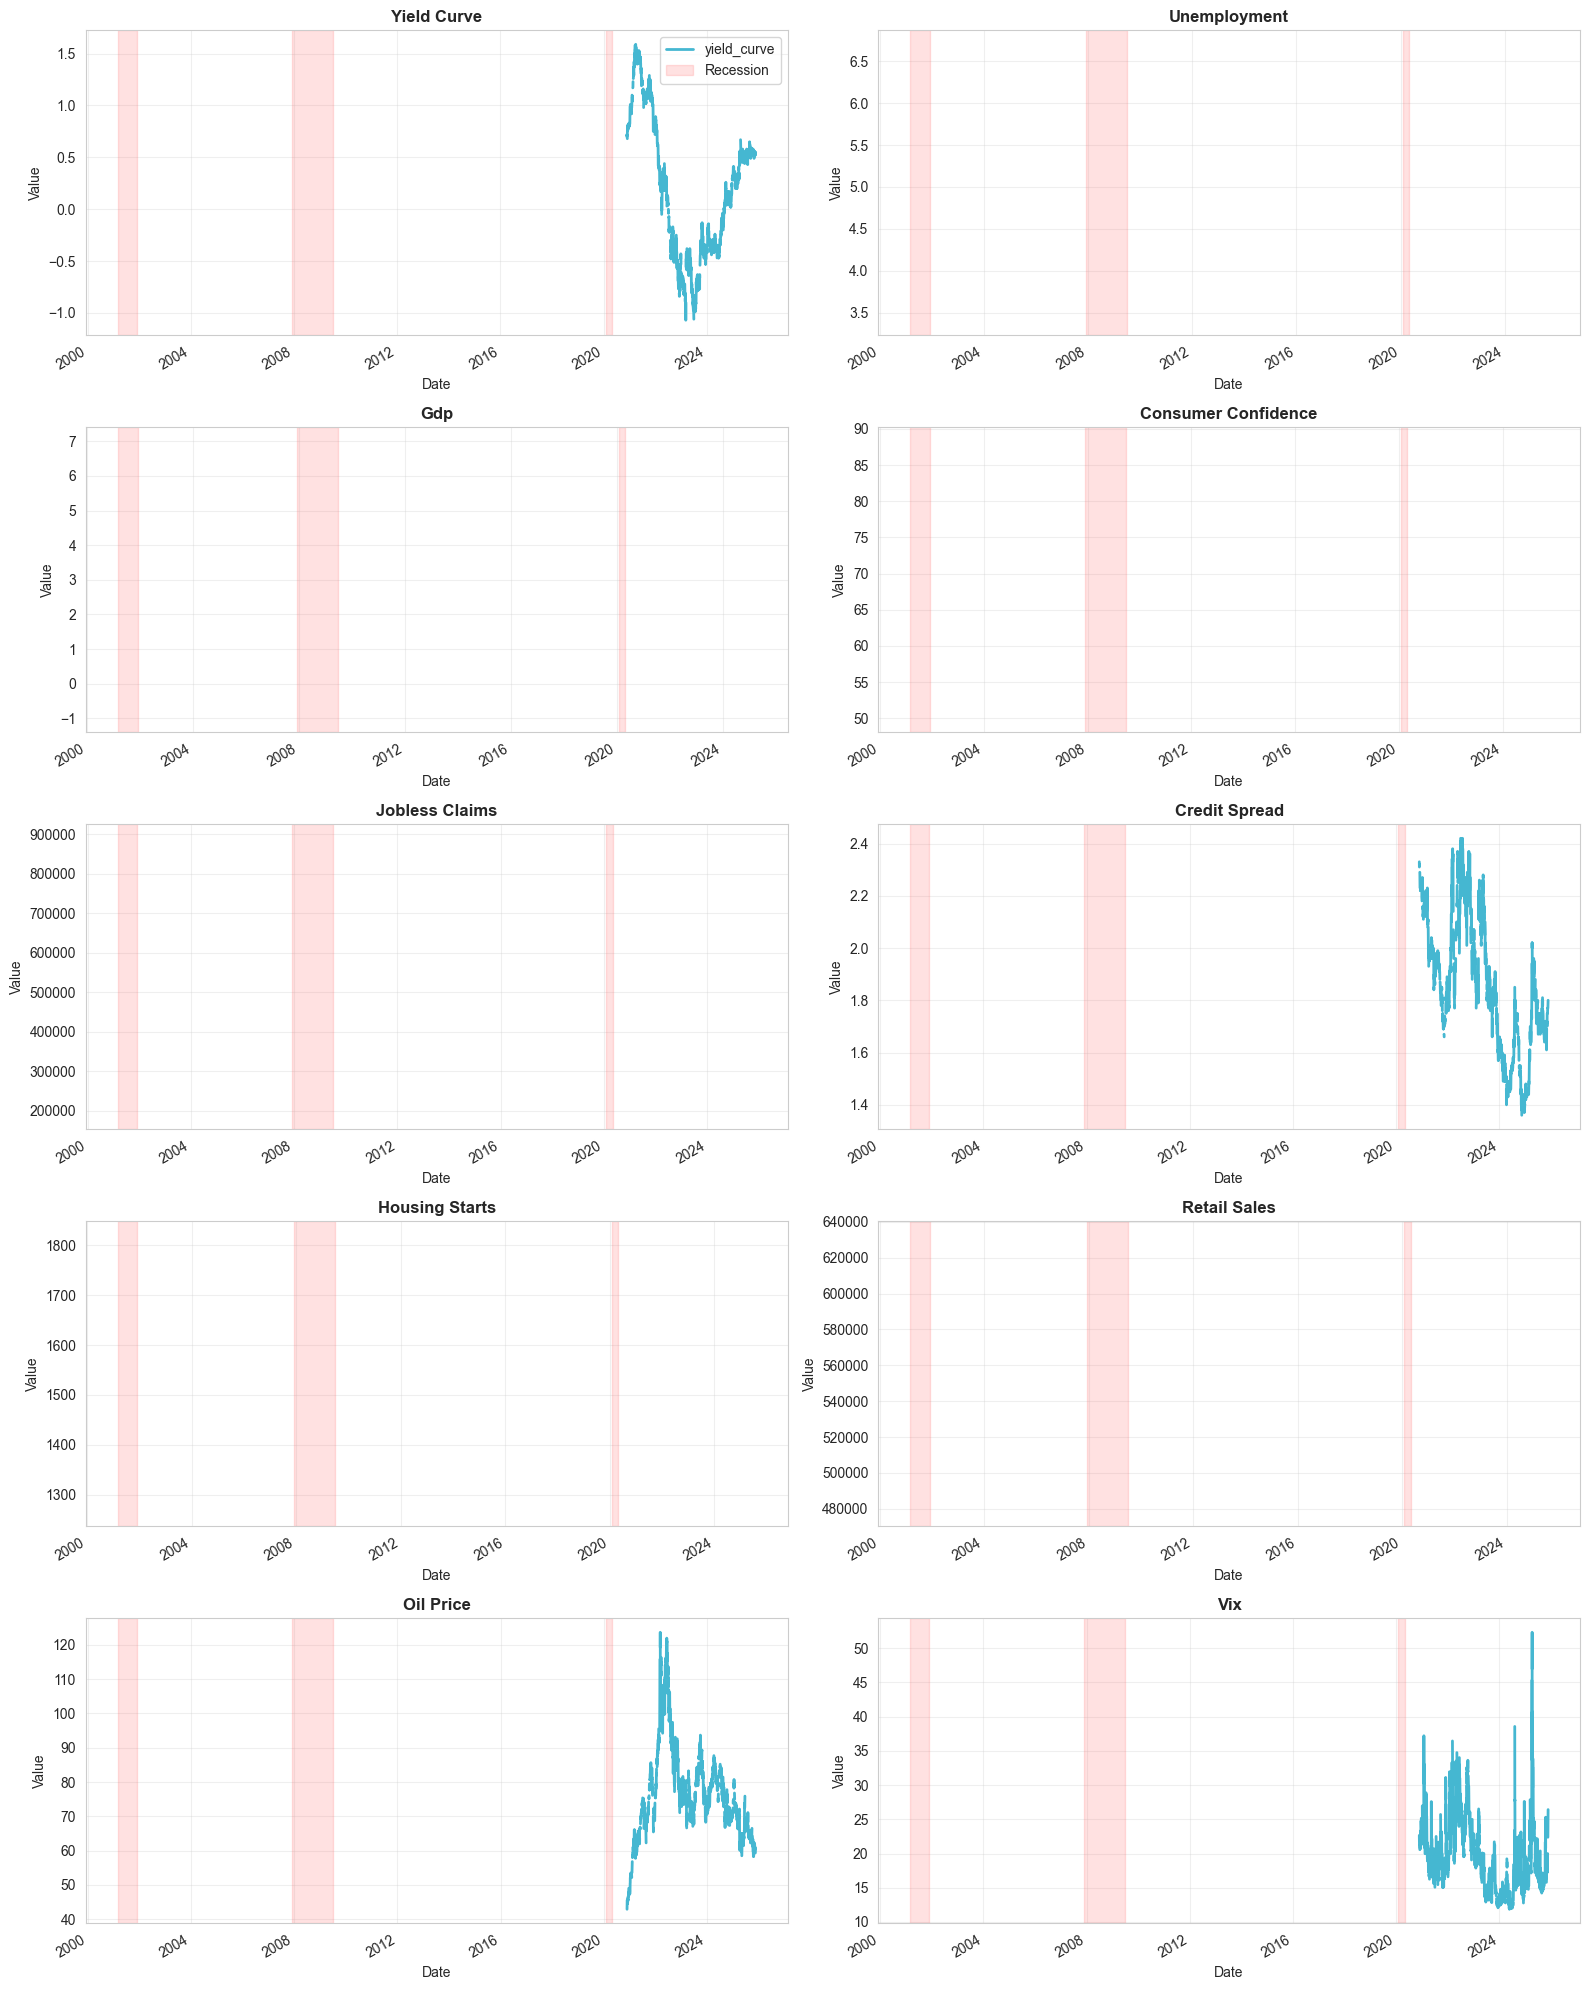

In [8]:
def mark_recessions(ax):
    """Mark recession periods on a plot."""
    for start, end in recession_periods:
        ax.axvspan(start, end, alpha=0.2, color='#ff6b6b', label='Recession' if start == recession_periods[0][0] else '')

# Plot each indicator
n_indicators = len(combined_df.columns)
n_cols = 2
n_rows = (n_indicators + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_indicators > 1 else [axes]

for idx, indicator_name in enumerate(combined_df.columns):
    ax = axes[idx]
    
    # Plot the indicator
    combined_df[indicator_name].plot(ax=ax, linewidth=2, color='#45b7d1')
    
    # Mark recessions
    mark_recessions(ax)
    
    ax.set_title(f"{indicator_name.replace('_', ' ').title()}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    
    # Add legend only to first plot
    if idx == 0:
        ax.legend()

# Hide extra subplots
for idx in range(n_indicators, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Statistical Summaries

Calculate descriptive statistics for each indicator.

In [9]:
# Calculate statistics
stats_df = combined_df.describe().T
stats_df['missing'] = combined_df.isnull().sum()
stats_df['missing_pct'] = (stats_df['missing'] / len(combined_df) * 100).round(2)

# Reorder columns
stats_df = stats_df[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing', 'missing_pct']]

print("Statistical Summary of Economic Indicators")
print("=" * 100)
display(stats_df.round(2))

Statistical Summary of Economic Indicators


,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
yield_curve,1250.0,0.17,0.68,-1.08,-0.39,0.16,0.59,1.59,324,20.58
unemployment,59.0,4.26,0.88,3.40,3.65,4.00,4.20,6.70,1515,96.25
gdp,19.0,3.12,2.20,-1.00,2.20,3.30,4.20,7.00,1555,98.79
consumer_confidence,60.0,67.31,9.23,50.00,59.88,67.30,72.05,88.30,1514,96.19
jobless_claims,260.0,281488.46,151887.19,189000.00,214000.00,224000.00,243500.00,890000.00,1314,83.48
credit_spread,1246.0,1.86,0.25,1.36,1.67,1.84,2.05,2.42,328,20.84
housing_starts,58.0,1474.28,138.13,1265.00,1362.75,1432.00,1578.50,1820.00,1516,96.32
retail_sales,58.0,578982.76,36387.10,478079.00,561137.00,586225.50,600273.75,632490.00,1516,96.32
oil_price,1244.0,76.36,13.49,42.91,68.34,74.46,82.50,123.64,330,20.97
vix,1281.0,19.44,5.28,11.86,15.66,18.34,22.17,52.33,293,18.61


## Distribution Analysis

Visualize the distribution of each indicator to identify outliers and understand data characteristics.

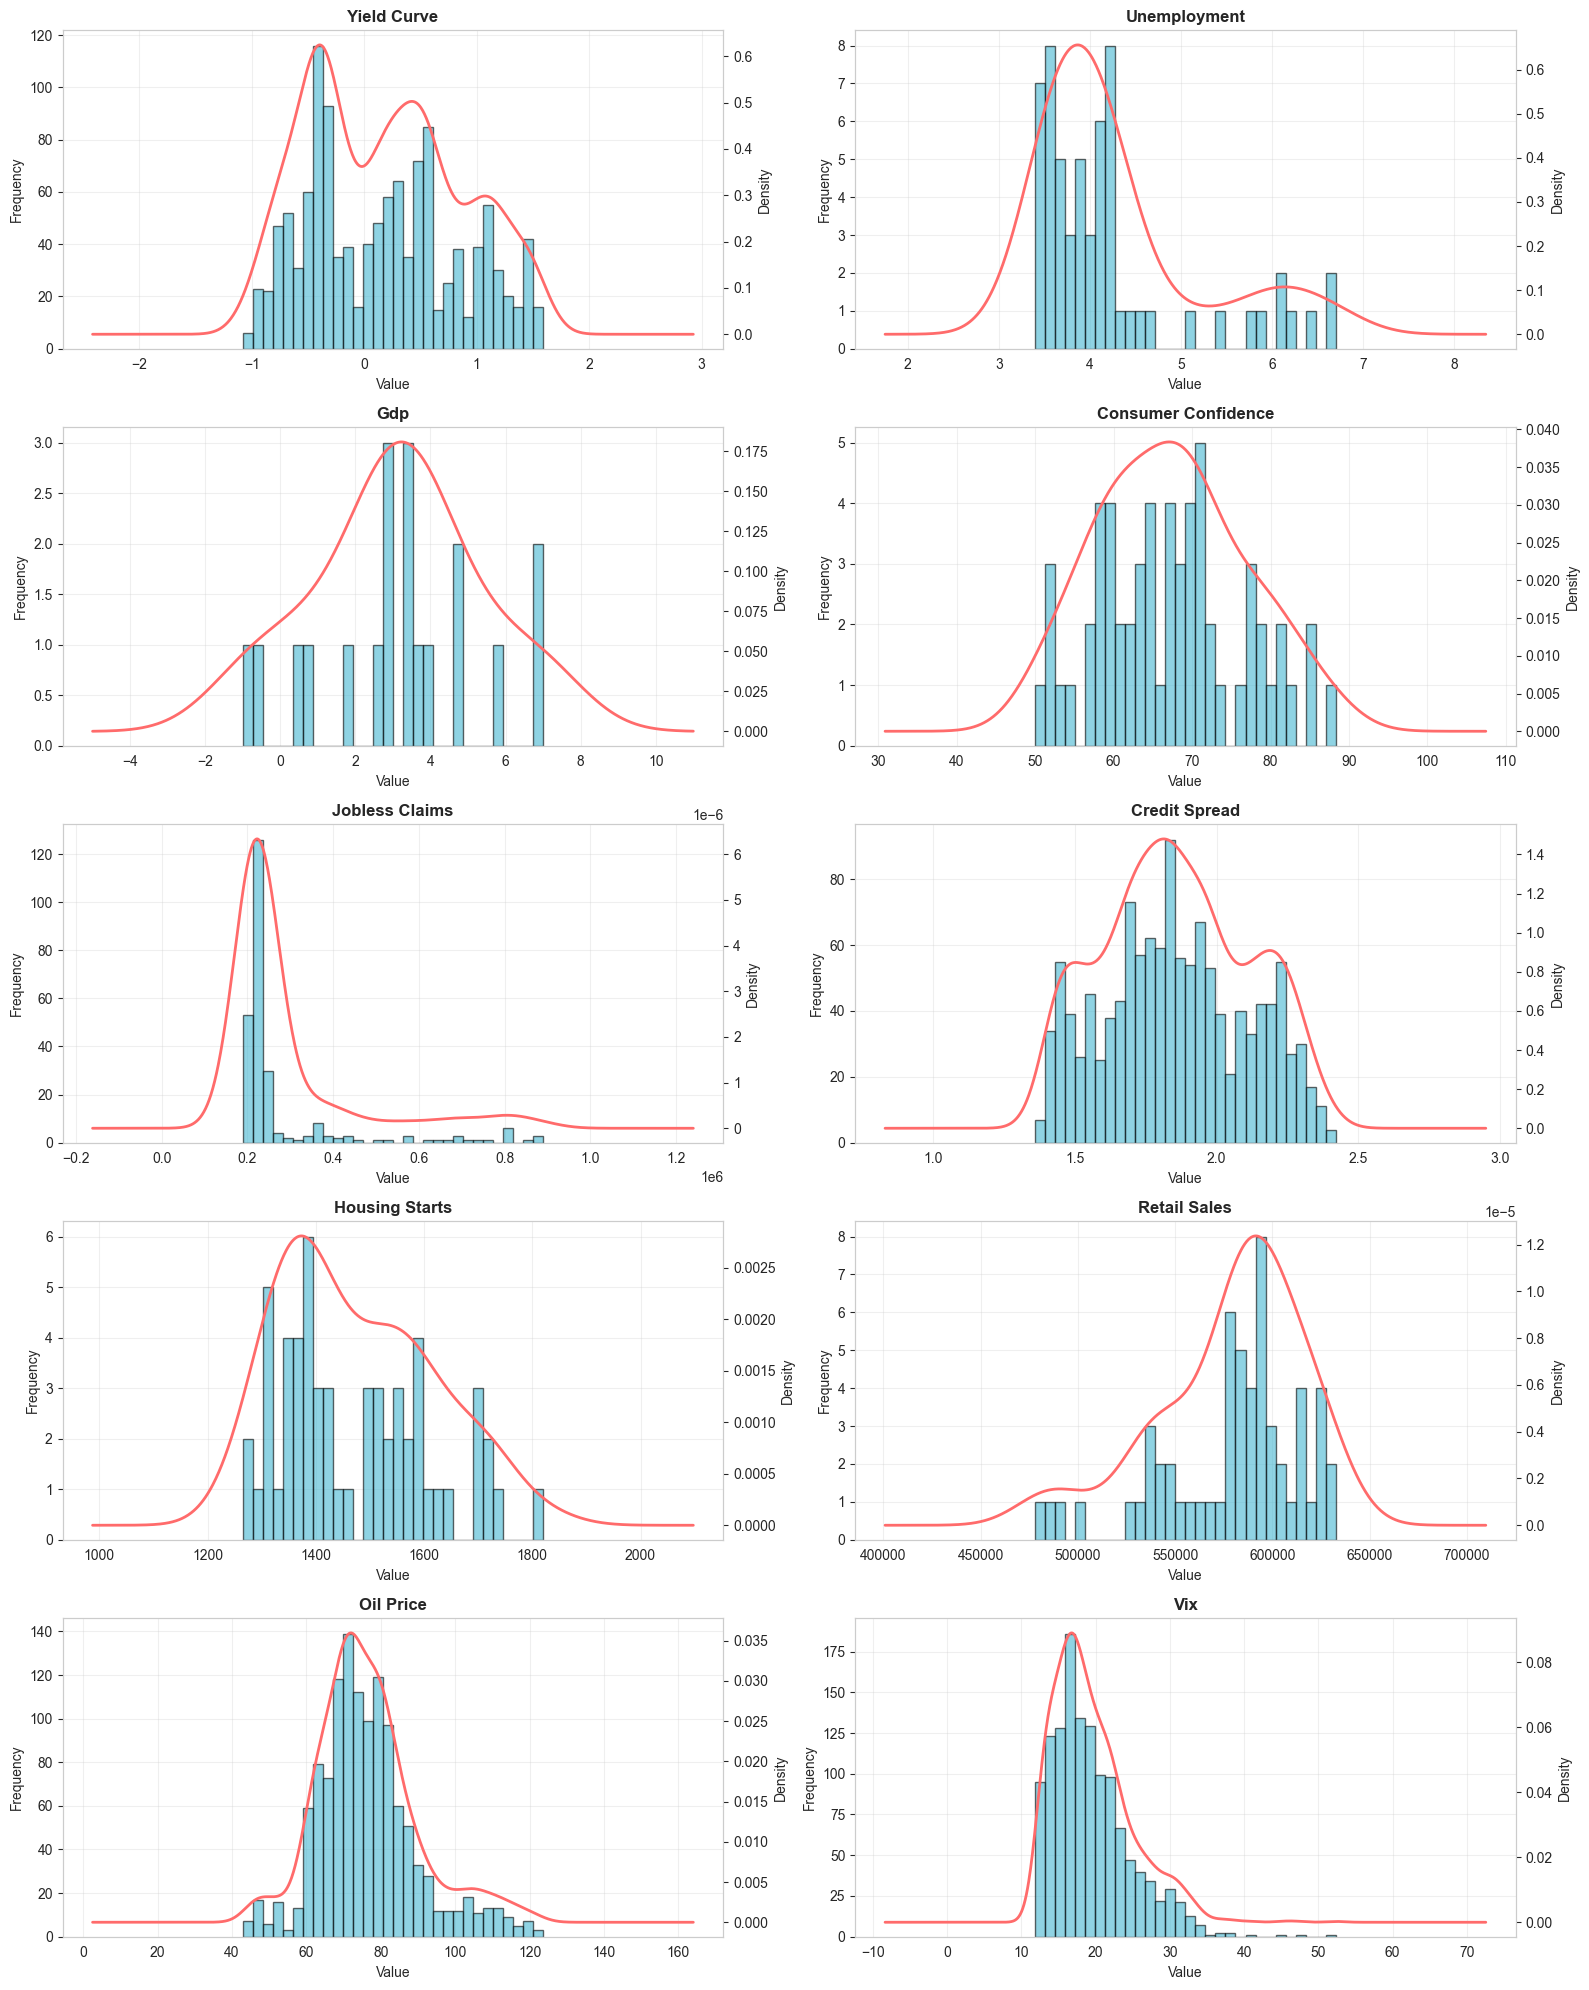

In [11]:
# Create distribution plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_indicators > 1 else [axes]

for idx, indicator_name in enumerate(combined_df.columns):
    ax = axes[idx]
    
    # Plot histogram with KDE
    data = combined_df[indicator_name].dropna()
    if len(data) > 0:
        data.hist(ax=ax, bins=30, alpha=0.6, color='#45b7d1', edgecolor='black')
        ax2 = ax.twinx()
        data.plot.kde(ax=ax2, color='#ff6b6b', linewidth=2)
        ax2.set_ylabel('Density')
        ax2.grid(False)
    
    ax.set_title(f"{indicator_name.replace('_', ' ').title()}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# Hide extra subplots
for idx in range(n_indicators, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# Identify outliers using IQR method
outliers_summary = []

for indicator_name in combined_df.columns:
    data = combined_df[indicator_name].dropna()
    if len(data) == 0:
        continue
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    outliers_summary.append({
        'Indicator': indicator_name,
        'Total Observations': len(data),
        'Outliers': len(outliers),
        'Outlier %': f"{len(outliers) / len(data) * 100:.2f}%",
        'Lower Bound': f"{lower_bound:.2f}",
        'Upper Bound': f"{upper_bound:.2f}"
    })

outliers_df = pd.DataFrame(outliers_summary)
print("\nOutlier Detection (IQR Method)")
print("=" * 100)
display(outliers_df)


Outlier Detection (IQR Method)


,Indicator,Total Observations,Outliers,Outlier %,Lower Bound,Upper Bound
0,yield_curve,1250,0,0.00%,-1.86,2.06
1,unemployment,59,10,16.95%,2.83,5.03
2,gdp,19,1,5.26%,-0.80,7.20
3,consumer_confidence,60,0,0.00%,41.61,90.31
4,jobless_claims,260,47,18.08%,169750.00,287750.00
5,credit_spread,1246,0,0.00%,1.11,2.62
6,housing_starts,58,0,0.00%,1039.12,1902.12
7,retail_sales,58,4,6.90%,502431.88,658978.88
8,oil_price,1244,84,6.75%,47.11,103.74
9,vix,1281,33,2.58%,5.89,31.94


## Correlation Analysis

Analyze correlations between indicators to understand relationships and potential multicollinearity.

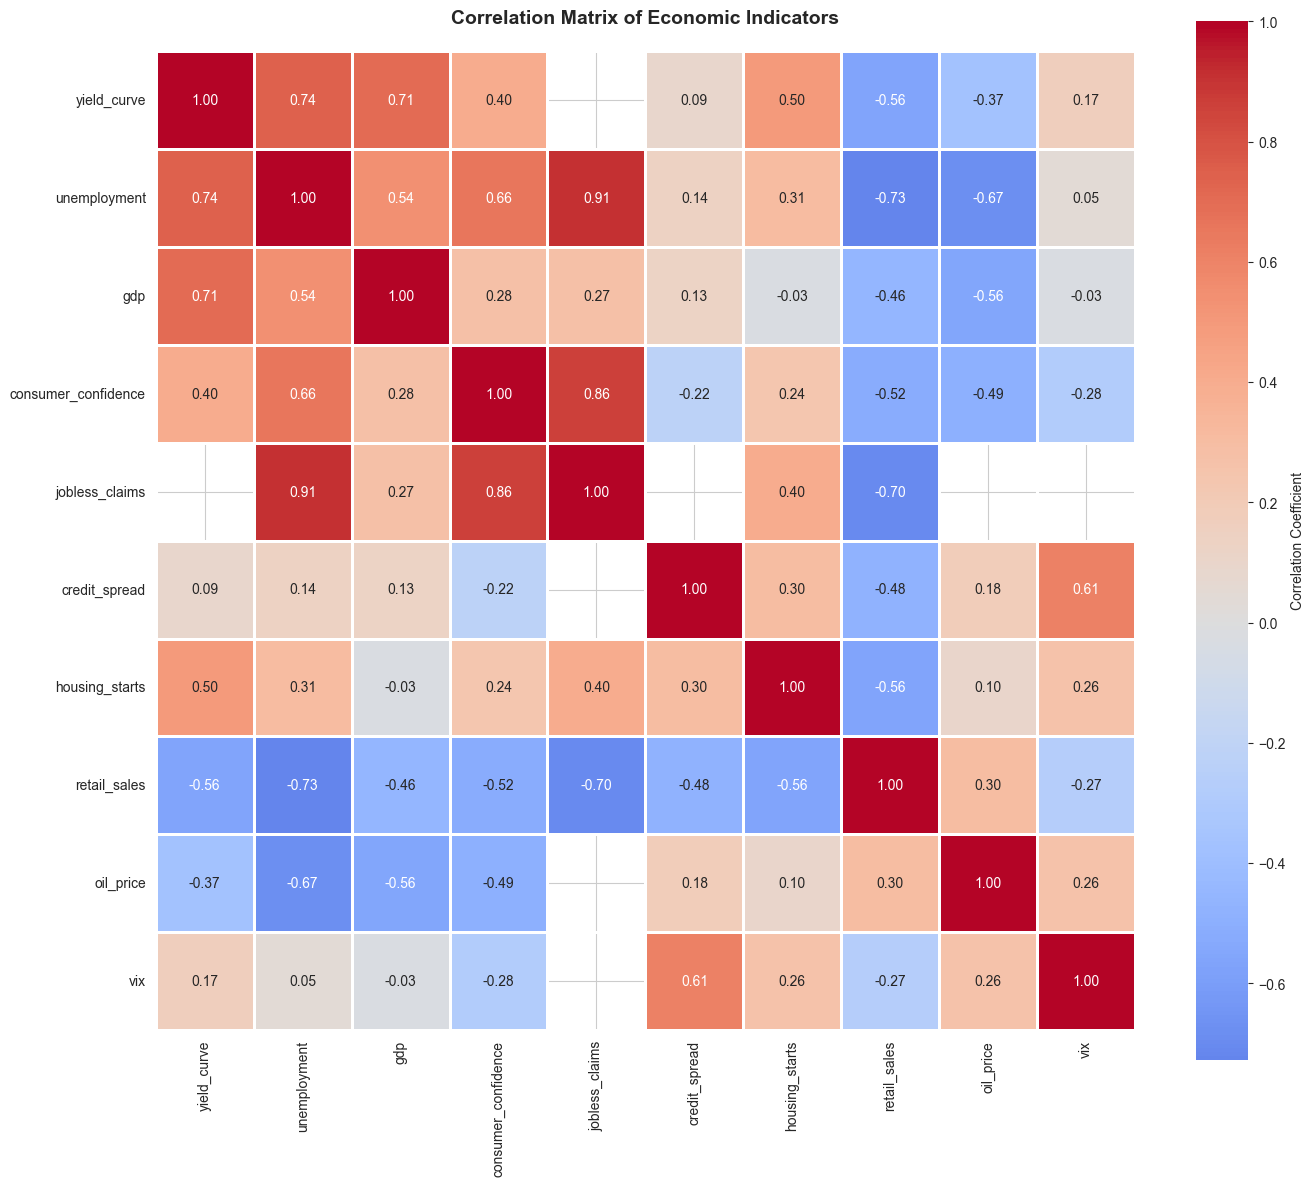

In [13]:
# Calculate correlation matrix
correlation_matrix = combined_df.corr()

# Create heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Economic Indicators', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [14]:
# Find highly correlated pairs (|correlation| > 0.7)
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'Indicator 1': correlation_matrix.columns[i],
                'Indicator 2': correlation_matrix.columns[j],
                'Correlation': f"{corr_value:.3f}"
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("\nHighly Correlated Indicator Pairs (|r| > 0.7)")
    print("=" * 80)
    display(high_corr_df)
else:
    print("\nNo highly correlated pairs found (|r| > 0.7)")


Highly Correlated Indicator Pairs (|r| > 0.7)


,Indicator 1,Indicator 2,Correlation
0,yield_curve,unemployment,0.744
1,yield_curve,gdp,0.706
2,unemployment,jobless_claims,0.910
3,unemployment,retail_sales,-0.727
4,consumer_confidence,jobless_claims,0.860
5,jobless_claims,retail_sales,-0.704


## Missing Data Analysis

Identify gaps in time series and visualize data availability.

In [15]:
# Calculate missing data statistics
missing_data = combined_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_data / len(combined_df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_pct,
    'Available Count': len(combined_df) - missing_data
})

print("Missing Data Summary")
print("=" * 80)
display(missing_summary)

Missing Data Summary


,Missing Count,Missing %,Available Count
gdp,1555,98.79,19
housing_starts,1516,96.32,58
retail_sales,1516,96.32,58
unemployment,1515,96.25,59
consumer_confidence,1514,96.19,60
jobless_claims,1314,83.48,260
oil_price,330,20.97,1244
credit_spread,328,20.84,1246
yield_curve,324,20.58,1250
vix,293,18.61,1281


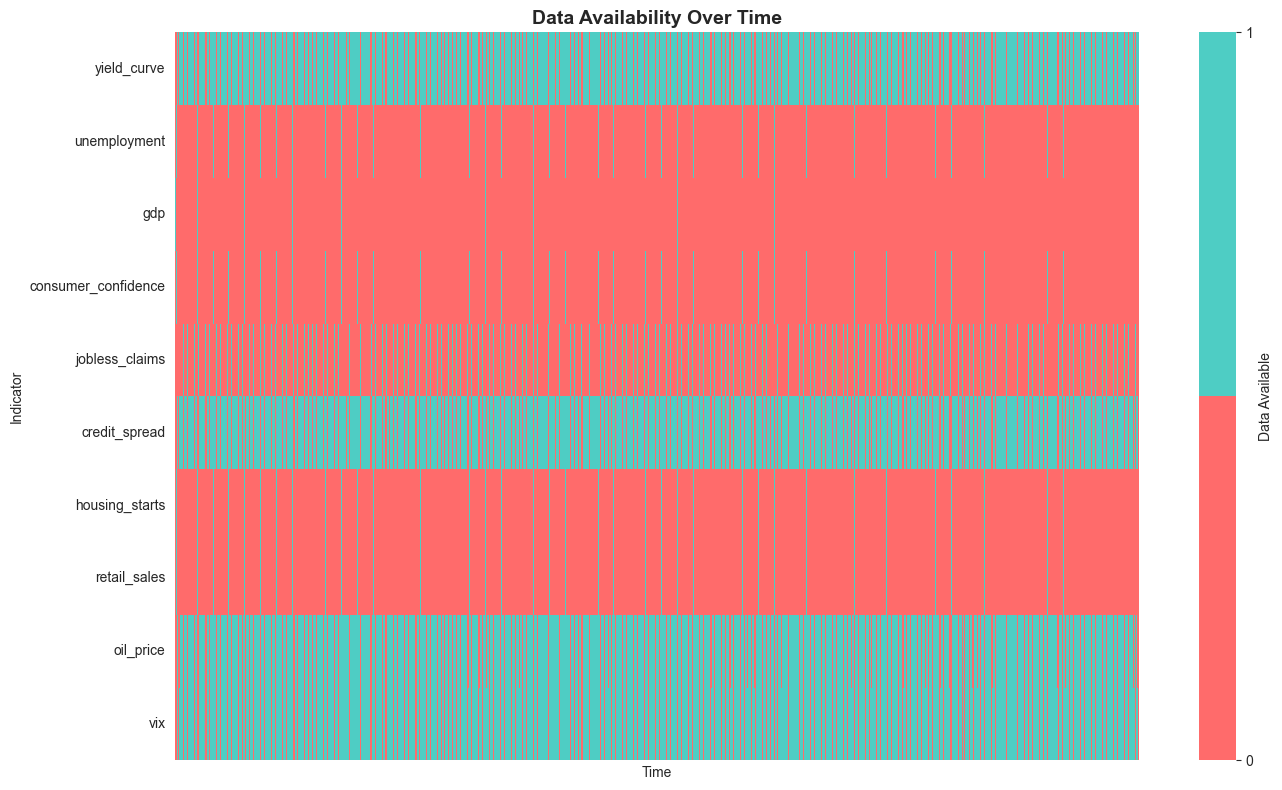

In [16]:
# Visualize missing data patterns
plt.figure(figsize=(14, 8))

# Create a binary matrix (1 = data available, 0 = missing)
availability_matrix = (~combined_df.isnull()).astype(int)

# Plot heatmap
sns.heatmap(
    availability_matrix.T,
    cmap=['#ff6b6b', '#4ecdc4'],
    cbar_kws={'label': 'Data Available', 'ticks': [0, 1]},
    yticklabels=combined_df.columns,
    xticklabels=False
)
plt.title('Data Availability Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Indicator')
plt.tight_layout()
plt.show()

## Data Quality Issues

Document any data quality concerns identified during exploration.

In [17]:
# Identify data quality issues
quality_issues = []

for indicator_name in combined_df.columns:
    data = combined_df[indicator_name]
    
    issues = []
    
    # Check for missing data
    missing_pct = data.isnull().sum() / len(data) * 100
    if missing_pct > 10:
        issues.append(f"High missing data: {missing_pct:.1f}%")
    
    # Check for gaps in time series
    non_null_data = data.dropna()
    if len(non_null_data) > 1:
        gaps = non_null_data.index.to_series().diff()
        max_gap = gaps.max()
        if max_gap > timedelta(days=90):
            issues.append(f"Large gap detected: {max_gap.days} days")
    
    # Check for constant values
    if len(non_null_data) > 0 and non_null_data.std() < 0.01:
        issues.append("Nearly constant values detected")
    
    if issues:
        quality_issues.append({
            'Indicator': indicator_name,
            'Issues': '; '.join(issues)
        })

if quality_issues:
    quality_df = pd.DataFrame(quality_issues)
    print("\nData Quality Issues")
    print("=" * 80)
    display(quality_df)
else:
    print("\n✓ No significant data quality issues detected")


Data Quality Issues


,Indicator,Issues
0,yield_curve,High missing data: 20.6%
1,unemployment,High missing data: 96.3%
2,gdp,High missing data: 98.8%; Large gap detected: ...
3,consumer_confidence,High missing data: 96.2%
4,jobless_claims,High missing data: 83.5%
5,credit_spread,High missing data: 20.8%
6,housing_starts,High missing data: 96.3%
7,retail_sales,High missing data: 96.3%
8,oil_price,High missing data: 21.0%
9,vix,High missing data: 18.6%


## Summary and Conclusions

### Key Findings

1. **Data Coverage**: We have successfully loaded 5 years of historical data for all economic indicators.

2. **Recession Patterns**: Visual inspection shows how indicators behaved during historical recession periods (2001, 2007-2009, 2020).

3. **Correlations**: The correlation analysis reveals relationships between indicators that may inform feature engineering and model design.

4. **Data Quality**: Missing data patterns and outliers have been identified for consideration in the modeling process.

### Next Steps

1. **Indicator Analysis** (Notebook 02): Deep dive into individual indicators and their predictive power
2. **Model Comparison** (Notebook 03): Compare v1 and v2 model performance
3. **Backtesting** (Notebook 04): Evaluate historical model performance
4. **Temporal Calibration** (Notebook 05): Calibrate temporal decay parameters